Using torch device: cpu
Train shape: torch.Size([256, 1]) torch.Size([256, 1])
=== Training PQC-3 (Random Init) ===


/usr/local/lib/python3.12/dist-packages/pennylane/devices/device_api.py:193: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


[PQC-3 Rand] Epoch   1 | train_mse=0.93942 | test_mse=0.75435
[PQC-3 Rand] Epoch  10 | train_mse=0.35951 | test_mse=0.34879
[PQC-3 Rand] Epoch  20 | train_mse=0.27244 | test_mse=0.27448
[PQC-3 Rand] Epoch  30 | train_mse=0.23302 | test_mse=0.23472
[PQC-3 Rand] Epoch  40 | train_mse=0.16365 | test_mse=0.17217
[PQC-3 Rand] Epoch  50 | train_mse=0.14696 | test_mse=0.15274
[PQC-3 Rand] Epoch  60 | train_mse=0.14080 | test_mse=0.14564

=== Convex Initialization of PQC-3 (Algorithm-1 Stage-1) ===
[Convex Init] Epoch  1 | grad²/dim=3.632e-03
✅ Convex-init exit: gradient threshold reached.

=== Training PQC-3 (Convex-Initialized) ===
[PQC-3 Convex] Epoch   1 | train_mse=0.96998 | test_mse=0.78568
[PQC-3 Convex] Epoch  10 | train_mse=0.41001 | test_mse=0.38857
[PQC-3 Convex] Epoch  20 | train_mse=0.20496 | test_mse=0.20945
[PQC-3 Convex] Epoch  30 | train_mse=0.16623 | test_mse=0.17556
[PQC-3 Convex] Epoch  40 | train_mse=0.13739 | test_mse=0.14350
[PQC-3 Convex] Epoch  50 | train_mse=0.12441 |

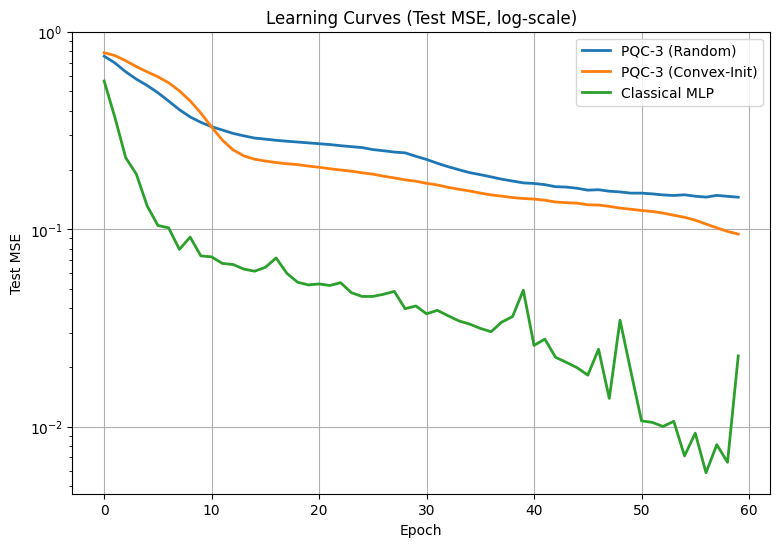

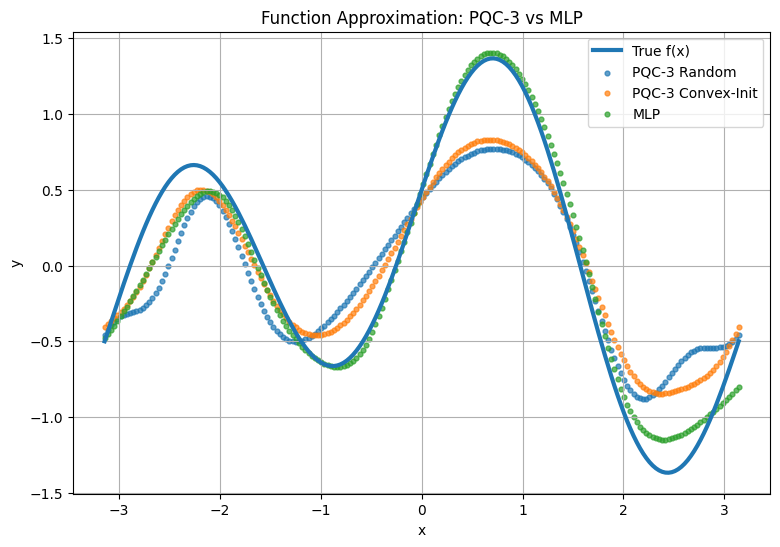

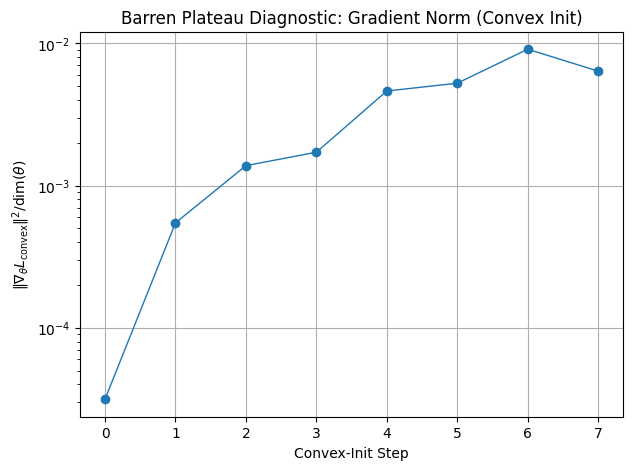


Figures saved to:
  - qml_outputs/learning_curves_pqc3.pdf
  - qml_outputs/function_fit_pqc3.pdf
  - qml_outputs/convex_init_grad_norm.pdf


In [4]:
# ============================================================
# PQC-3 Random vs Convex-Initialized Benchmark
# (Algorithm 1 Stage-1 for Barren Plateaus)
# PennyLane + PyTorch
#
# Models:
#   - PQC-3 (Random initialization, standard regression)
#   - PQC-3 (Convex quadratic initialization, Algorithm-1 Stage-1)
#   - Classical MLP baseline (He/Xavier)
#
# Extras:
#   - Learning curves (Test MSE)
#   - Shot-noise simulation (finite shots)
#   - Noisy channels (Depolarizing + Amplitude Damping)
#   - Barren plateau diagnostics (Convex-init gradient norm history)
#   - Hardware-compatible gates (IBM-style: RX, RZ, CNOT)
#   - Auto-generated CSV + LaTeX table and PDF plots
#
# Author: Boabang Francis (with ChatGPT scaffold)
# ============================================================

# 0. INSTALLS (uncomment in Colab)
# !pip install pennylane pennylane-lightning pennylane-qchem
# !pip install torch matplotlib pandas

import math
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import pandas as pd
import pennylane as qml
from pathlib import Path

# ------------------------------------------------------------
# Global setup
# ------------------------------------------------------------
np.random.seed(42)
torch.manual_seed(42)

device_torch = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using torch device:", device_torch)

# Directory for saving figures / tables
out_dir = Path("./qml_outputs")
out_dir.mkdir(exist_ok=True)

# ============================================================
# 1. Toy Dataset: Nonlinear Regression
#    y = sin(2x) + 0.5 cos(x)
# ============================================================

def make_regression_dataset(n_samples=256, x_range=(-math.pi, math.pi)):
    xs = np.random.uniform(x_range[0], x_range[1], size=(n_samples, 1))
    ys = np.sin(2 * xs) + 0.5 * np.cos(xs)   # nonlinear target
    xs = xs.astype(np.float32)
    ys = ys.astype(np.float32)
    return xs, ys

X_train, y_train = make_regression_dataset(256)
X_test,  y_test  = make_regression_dataset(128)

X_train_t = torch.from_numpy(X_train).to(device_torch)
y_train_t = torch.from_numpy(y_train).to(device_torch)
X_test_t  = torch.from_numpy(X_test).to(device_torch)
y_test_t  = torch.from_numpy(y_test).to(device_torch)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

print("Train shape:", X_train_t.shape, y_train_t.shape)

# ============================================================
# 2. Quantum Devices (Analytic, Shot-based, Noisy)
# ============================================================

N_QUBITS = 4

# Ideal analytic device (no noise, infinite shots)
dev_analytic = qml.device("default.qubit", wires=N_QUBITS, shots=None)

# Shot-based device (shot noise)
SHOTS = 1000
dev_shots = qml.device("default.qubit", wires=N_QUBITS, shots=SHOTS)

# Noisy mixed-state device for depolarizing + amplitude damping
dev_noisy = qml.device("default.mixed", wires=N_QUBITS)

# ============================================================
# 3. Classical-to-Quantum Feature Encoding
#    Map scalar x → R^4 and use AngleEmbedding.
# ============================================================

def encode_x_to_features(x_scalar, n_qubits=N_QUBITS):
    """
    Map scalar x to a feature vector R^{n_qubits}.
    Here: simple linear + trigonometric features.
    """
    x = x_scalar
    feats = [
        x,            # linear
        x**2,         # quadratic
        torch.sin(x), # nonlinear
        torch.cos(x)
    ]
    feats = feats[:n_qubits]
    return torch.stack(feats)

# ============================================================
# 4. Hardware-Compatible PQC Ansätze (IBM-style)
#    Gates: RX, RZ, CNOT (all native on IBM).
# ============================================================

def pqc3_ansatz(features, weights):
    """
    PQC-3 (deeper) ansatz.
    features: (n_qubits,)
    weights:  (n_layers, n_qubits, 2)
    """
    qml.AngleEmbedding(features, wires=range(N_QUBITS), rotation="Y")
    n_layers = weights.shape[0]

    for layer in range(n_layers):
        for i in range(N_QUBITS):
            qml.RX(weights[layer, i, 0], wires=i)
            qml.RZ(weights[layer, i, 1], wires=i)
        for i in range(N_QUBITS - 1):
            qml.CNOT(wires=[i, i + 1])
        qml.CNOT(wires=[N_QUBITS - 1, 0])

# ============================================================
# 5. QNodes (Analytic / Shot-based / Noisy)
# ============================================================

@qml.qnode(dev_analytic, interface="torch")
def pqc3_qnode(x_scalar, weights):
    feats = encode_x_to_features(x_scalar)
    pqc3_ansatz(feats, weights)
    return qml.expval(qml.PauliZ(0))

@qml.qnode(dev_shots, interface="torch")
def pqc3_qnode_shots(x_scalar, weights):
    feats = encode_x_to_features(x_scalar)
    pqc3_ansatz(feats, weights)
    return qml.expval(qml.PauliZ(0))

@qml.qnode(dev_noisy, interface="torch")
def pqc3_qnode_noisy(x_scalar, weights, p_dep=0.02, gamma_amp=0.03):
    feats = encode_x_to_features(x_scalar)
    pqc3_ansatz(feats, weights)

    # Depolarizing noise (each qubit)
    for i in range(N_QUBITS):
        qml.DepolarizingChannel(p_dep, wires=i)

    # Amplitude damping (each qubit)
    for i in range(N_QUBITS):
        qml.AmplitudeDamping(gamma_amp, wires=i)

    return qml.expval(qml.PauliZ(0))

# ============================================================
# 6. Torch Wrappers: PQC-3
# ============================================================

class PQC3Model(nn.Module):
    def __init__(self, n_qubits=N_QUBITS, n_layers=3):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.weights = nn.Parameter(0.01 * torch.randn(n_layers, n_qubits, 2))

    def forward(self, x_batch):
        out = []
        for x in x_batch:
            out.append(pqc3_qnode(x[0], self.weights))
        return torch.stack(out).unsqueeze(-1)  # (batch, 1)

# ============================================================
# 7. Classical MLP Baseline
# ============================================================

class MLPBaseline(nn.Module):
    def __init__(self, in_dim=1, hidden_dim=32, out_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        # x: (batch, 1)
        return self.net(x)

# ============================================================
# 8. Training & Evaluation Utilities
# ============================================================

def train_epoch(model, loader, optimizer, l2_lambda=0.0):
    model.train()
    total_loss = 0.0
    total_n = 0

    for xb, yb in loader:
        xb = xb.to(device_torch)
        yb = yb.to(device_torch)

        optimizer.zero_grad()
        preds = model(xb)  # (batch, 1)
        mse = torch.mean((preds - yb) ** 2)

        l2_reg = torch.tensor(0.0, device=device_torch)
        if l2_lambda > 0:
            for p in model.parameters():
                l2_reg = l2_reg + torch.sum(p ** 2)

        loss = mse + l2_lambda * l2_reg
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        total_n += xb.size(0)

    return total_loss / total_n


def eval_mse(model, loader):
    model.eval()
    total_mse = 0.0
    total_n = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device_torch)
            yb = yb.to(device_torch)
            preds = model(xb)
            mse = torch.mean((preds - yb) ** 2)
            total_mse += mse.item() * xb.size(0)
            total_n += xb.size(0)
    return total_mse / total_n


def eval_shot_mse(pqc3_model, loader):
    """
    Evaluate PQC-3 under finite shots (shot noise).
    """
    pqc3_model.eval()
    total_mse, total_n = 0.0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device_torch), yb.to(device_torch)
            preds = []
            for x in xb:
                preds.append(pqc3_qnode_shots(x[0], pqc3_model.weights))
            preds = torch.stack(preds).unsqueeze(-1)
            mse = torch.mean((preds - yb) ** 2)
            total_mse += mse.item() * xb.size(0)
            total_n += xb.size(0)
    return total_mse / total_n


def eval_noisy_mse(pqc3_model, loader, p_dep=0.02, gamma_amp=0.03):
    """
    Evaluate PQC-3 under depolarizing + amplitude damping noise.
    """
    pqc3_model.eval()
    total_mse, total_n = 0.0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device_torch), yb.to(device_torch)
            preds = []
            for x in xb:
                preds.append(pqc3_qnode_noisy(x[0], pqc3_model.weights,
                                              p_dep=p_dep, gamma_amp=gamma_amp))
            preds = torch.stack(preds).unsqueeze(-1)
            mse = torch.mean((preds - yb) ** 2)
            total_mse += mse.item() * xb.size(0)
            total_n += xb.size(0)
    return total_mse / total_n

# ============================================================
# 9. Helpers for Convex Initialization (Algorithm-1 Stage-1)
# ============================================================

def grad_norm_sq_per_dim(model):
    """
    ||∇θ L||^2 / dim(θ)  (assumes backward() has been called)
    """
    total = 0.0
    dim = 0
    for p in model.parameters():
        if p.grad is not None:
            total += (p.grad ** 2).sum()
            dim += p.numel()
    if dim == 0:
        return 0.0
    return (total / dim).item()


def convex_init_pqc3_regression(
    model,
    loader,
    tau_g=1e-4,
    max_epochs=50,
    lr=0.02
):
    """
    Convex quadratic pre-conditioning:
        L_convex(θ) = E[(f_θ(x))^2]
    convex in outputs (used as Stage-1 of Algorithm-1).
    """
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    grad_hist = []

    for ep in range(1, max_epochs + 1):
        model.train()
        total_g2 = 0.0
        n_batches = 0

        for xb, _ in loader:
            xb = xb.to(device_torch)

            opt.zero_grad()
            preds = model(xb)

            # Strictly convex quadratic surrogate
            L_convex = torch.mean(preds ** 2)
            L_convex.backward()

            g2 = grad_norm_sq_per_dim(model)
            grad_hist.append(g2)
            total_g2 += g2
            n_batches += 1

            opt.step()

        mean_g2 = total_g2 / max(1, n_batches)
        print(f"[Convex Init] Epoch {ep:2d} | grad²/dim={mean_g2:.3e}")

        if mean_g2 >= tau_g:
            print("✅ Convex-init exit: gradient threshold reached.")
            break

    return grad_hist

# ============================================================
# 10. Learning-Curve Containers
# ============================================================

curve = {
    "pqc3_rand_train": [], "pqc3_rand_test": [],
    "pqc3_conv_train": [], "pqc3_conv_test": [],
    "mlp_train": [],       "mlp_test": []
}

convex_grad_history = []  # for barren plateau diagnostics

# ============================================================
# 11. PQC-3 (Random Initialization, Standard Regression)
# ============================================================

pqc3_rand = PQC3Model(n_qubits=N_QUBITS, n_layers=3).to(device_torch)

with torch.no_grad():
    pqc3_rand.weights[:] = 0.01 * torch.randn_like(pqc3_rand.weights)

optimizer3_rand = torch.optim.Adam(pqc3_rand.parameters(), lr=0.01)
l2_lambda_pqc3_rand = 5e-4
EPOCHS_PQC3_RAND = 60

print("=== Training PQC-3 (Random Init) ===")
for epoch in range(1, EPOCHS_PQC3_RAND + 1):
    _ = train_epoch(
        pqc3_rand, train_loader, optimizer3_rand,
        l2_lambda=l2_lambda_pqc3_rand
    )
    train_mse = eval_mse(pqc3_rand, train_loader)
    test_mse  = eval_mse(pqc3_rand, test_loader)

    curve["pqc3_rand_train"].append(train_mse)
    curve["pqc3_rand_test"].append(test_mse)

    if epoch % 10 == 0 or epoch == 1:
        print(f"[PQC-3 Rand] Epoch {epoch:3d} | "
              f"train_mse={train_mse:.5f} | test_mse={test_mse:.5f}")

pqc3_rand_train_mse_final = eval_mse(pqc3_rand, train_loader)
pqc3_rand_test_mse_final  = eval_mse(pqc3_rand, test_loader)
n_params_pqc3 = sum(p.numel() for p in pqc3_rand.parameters())

# ============================================================
# 12. PQC-3 (Convex Quadratic Initialization + Standard Regression)
# ============================================================

pqc3_conv = PQC3Model(n_qubits=N_QUBITS, n_layers=3).to(device_torch)

with torch.no_grad():
    pqc3_conv.weights[:] = 0.01 * torch.randn_like(pqc3_conv.weights)

print("\n=== Convex Initialization of PQC-3 (Algorithm-1 Stage-1) ===")
convex_grad_history = convex_init_pqc3_regression(
    pqc3_conv,
    train_loader,
    tau_g=1e-4,
    max_epochs=50,
    lr=0.02
)

optimizer3_conv = torch.optim.Adam(pqc3_conv.parameters(), lr=0.01)
l2_lambda_pqc3_conv = 5e-4
EPOCHS_PQC3_CONV = 60

print("\n=== Training PQC-3 (Convex-Initialized) ===")
for epoch in range(1, EPOCHS_PQC3_CONV + 1):
    _ = train_epoch(
        pqc3_conv, train_loader, optimizer3_conv,
        l2_lambda=l2_lambda_pqc3_conv
    )
    train_mse = eval_mse(pqc3_conv, train_loader)
    test_mse  = eval_mse(pqc3_conv, test_loader)

    curve["pqc3_conv_train"].append(train_mse)
    curve["pqc3_conv_test"].append(test_mse)

    if epoch % 10 == 0 or epoch == 1:
        print(f"[PQC-3 Convex] Epoch {epoch:3d} | "
              f"train_mse={train_mse:.5f} | test_mse={test_mse:.5f}")

pqc3_conv_train_mse_final = eval_mse(pqc3_conv, train_loader)
pqc3_conv_test_mse_final  = eval_mse(pqc3_conv, test_loader)

# ============================================================
# 13. Classical MLP Baseline Training
# ============================================================

mlp_model = MLPBaseline().to(device_torch)
opt_mlp = torch.optim.Adam(mlp_model.parameters(), lr=0.01)
EPOCHS_MLP = 60

print("\n=== Training Classical MLP Baseline ===")
for epoch in range(1, EPOCHS_MLP + 1):
    _ = train_epoch(mlp_model, train_loader, opt_mlp, l2_lambda=1e-4)
    train_mse = eval_mse(mlp_model, train_loader)
    test_mse  = eval_mse(mlp_model, test_loader)

    curve["mlp_train"].append(train_mse)
    curve["mlp_test"].append(test_mse)

    if epoch % 10 == 0 or epoch == 1:
        print(f"[MLP] Epoch {epoch:3d} | train_mse={train_mse:.5f} "
              f"| test_mse={test_mse:.5f}")

mlp_train_mse_final = eval_mse(mlp_model, train_loader)
mlp_test_mse_final  = eval_mse(mlp_model, test_loader)
n_params_mlp = sum(p.numel() for p in mlp_model.parameters())

# ============================================================
# 14. Shot-Noise & Hardware Noise Evaluation (PQC-3 Rand vs Convex)
# ============================================================

print("\n=== Shot-Noise Evaluation (Test MSE) ===")
print("PQC-3 Rand   (shots):", eval_shot_mse(pqc3_rand, test_loader))
print("PQC-3 Convex (shots):", eval_shot_mse(pqc3_conv, test_loader))

print("\n=== Noisy Channel Evaluation (Test MSE) ===")
print("PQC-3 Rand   (noisy):", eval_noisy_mse(pqc3_rand, test_loader))
print("PQC-3 Convex (noisy):", eval_noisy_mse(pqc3_conv, test_loader))

# ============================================================
# 15. Results Table + LaTeX Export
# ============================================================

results = pd.DataFrame({
    "Model": [
        "PQC-3 (Random Init)",
        "PQC-3 (Convex-Init, Alg.1 Stage-1)",
        "Classical MLP"
    ],
    "Train MSE": [
        pqc3_rand_train_mse_final,
        pqc3_conv_train_mse_final,
        mlp_train_mse_final
    ],
    "Test MSE": [
        pqc3_rand_test_mse_final,
        pqc3_conv_test_mse_final,
        mlp_test_mse_final
    ],
    "Parameters": [
        n_params_pqc3,
        n_params_pqc3,
        n_params_mlp
    ]
})

print("\n=== COMPARISON TABLE ===")
print(results)

results.to_csv(out_dir / "pqc3_comparison.csv", index=False)

latex_table = results.to_latex(index=False, float_format="%.4f")
with open(out_dir / "pqc3_comparison.tex", "w") as f:
    f.write(latex_table)

print("\nLaTeX table saved to:", out_dir / "pqc3_comparison.tex")

# ============================================================
# 16. Plots: Learning Curves + Function Fits + Grad Norm
# ============================================================

def plot_learning_curves(curve_dict, savepath=None):
    plt.figure(figsize=(9,6))
    plt.plot(curve_dict["pqc3_rand_test"],   label="PQC-3 (Random)", linewidth=2)
    plt.plot(curve_dict["pqc3_conv_test"],   label="PQC-3 (Convex-Init)", linewidth=2)
    plt.plot(curve_dict["mlp_test"],         label="Classical MLP", linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Test MSE")
    plt.yscale("log")
    plt.title("Learning Curves (Test MSE, log-scale)")
    plt.legend()
    plt.grid(True)
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight", dpi=300)
    plt.show()

def plot_model_fit_three(model1, model2, model3,
                         labels=("PQC-3 Random", "PQC-3 Convex-Init", "MLP"),
                         x_range=(-math.pi, math.pi), n_points=200,
                         savepath=None):

    model1.eval(); model2.eval(); model3.eval()

    xs = torch.linspace(x_range[0], x_range[1], n_points).unsqueeze(-1).to(device_torch)
    with torch.no_grad():
        y_true = torch.sin(2 * xs) + 0.5 * torch.cos(xs)
        y1 = model1(xs)
        y2 = model2(xs)
        y3 = model3(xs)

    xs_np = xs.cpu().numpy().flatten()
    y_true_np = y_true.cpu().numpy().flatten()
    y1_np = y1.cpu().numpy().flatten()
    y2_np = y2.cpu().numpy().flatten()
    y3_np = y3.cpu().numpy().flatten()

    plt.figure(figsize=(9,6))
    plt.plot(xs_np, y_true_np, label="True f(x)", linewidth=3)
    plt.scatter(xs_np, y1_np, s=12, alpha=0.7, label=labels[0])
    plt.scatter(xs_np, y2_np, s=12, alpha=0.7, label=labels[1])
    plt.scatter(xs_np, y3_np, s=12, alpha=0.7, label=labels[2])
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Function Approximation: PQC-3 vs MLP")
    plt.legend()
    plt.grid(True)
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight", dpi=300)
    plt.show()

def plot_convex_grad_history(grad_hist, savepath=None):
    if len(grad_hist) == 0:
        return
    plt.figure(figsize=(7,5))
    plt.plot(grad_hist, marker="o", linewidth=1)
    plt.xlabel("Convex-Init Step")
    plt.ylabel(r"$\|\nabla_\theta L_{\mathrm{convex}}\|^2 / \dim(\theta)$")
    plt.yscale("log")
    plt.title("Barren Plateau Diagnostic: Gradient Norm (Convex Init)")
    plt.grid(True)
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight", dpi=300)
    plt.show()

# Generate and save plots
lc_path   = out_dir / "learning_curves_pqc3.pdf"
fit_path  = out_dir / "function_fit_pqc3.pdf"
grad_path = out_dir / "convex_init_grad_norm.pdf"

plot_learning_curves(curve, savepath=lc_path)
plot_model_fit_three(pqc3_rand, pqc3_conv, mlp_model, savepath=fit_path)
plot_convex_grad_history(convex_grad_history, savepath=grad_path)

print("\nFigures saved to:")
print("  -", lc_path)
print("  -", fit_path)
print("  -", grad_path)
